mình sẽ có thể phân tích gì dựa trên dataset này 

chất nào vượt quá tiêu chuẩn ngưỡng cho phép 

xu hướng của ô nhiễm không khí tăng hay giảm

ô nhiễm môi trường do đâu?

ô nhiễm cao nhất khi nào? (trong ngày, trong tuần, trong năm)

hiện nay nhà nước có chính sách siết chặc các xe có động cơ đốt trong vào thành phố vậy liệu động cơ đốt 
có gây ô nhiễm môi trường hay không 

dự trên kết quả phân tích thì mình sẽ làm được gì? 




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
file_name = "hcm_aqi_full_dataset.csv"
folder_path = "dataset"
file_path = os.path.join(folder_path, file_name)

df = pd.read_csv(file_path)

In [3]:
df.tail(5)

,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
26875,2026-01-24 19:00:00,23.3,20.9,717.0,31.5,87.0,11.5,136,0.0,26.4,66,0.0,13.1,159
26876,2026-01-24 20:00:00,20.3,18.1,652.0,30.9,76.0,11.3,124,0.0,25.4,71,0.0,12.5,150
26877,2026-01-24 21:00:00,18.0,16.0,593.0,27.8,71.0,10.7,105,0.0,24.4,78,0.0,10.4,144
26878,2026-01-24 22:00:00,16.8,15.0,547.0,25.6,67.0,10.2,82,0.0,24.1,81,0.0,8.5,144
26879,2026-01-24 23:00:00,16.4,14.7,518.0,25.6,62.0,10.0,79,0.0,23.7,82,0.0,7.8,116


C:\Users\nguye\AppData\Local\Temp\ipykernel_19968\986499779.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayOfWeek', y='AQI', data=df, order=days_order, palette='Oranges')


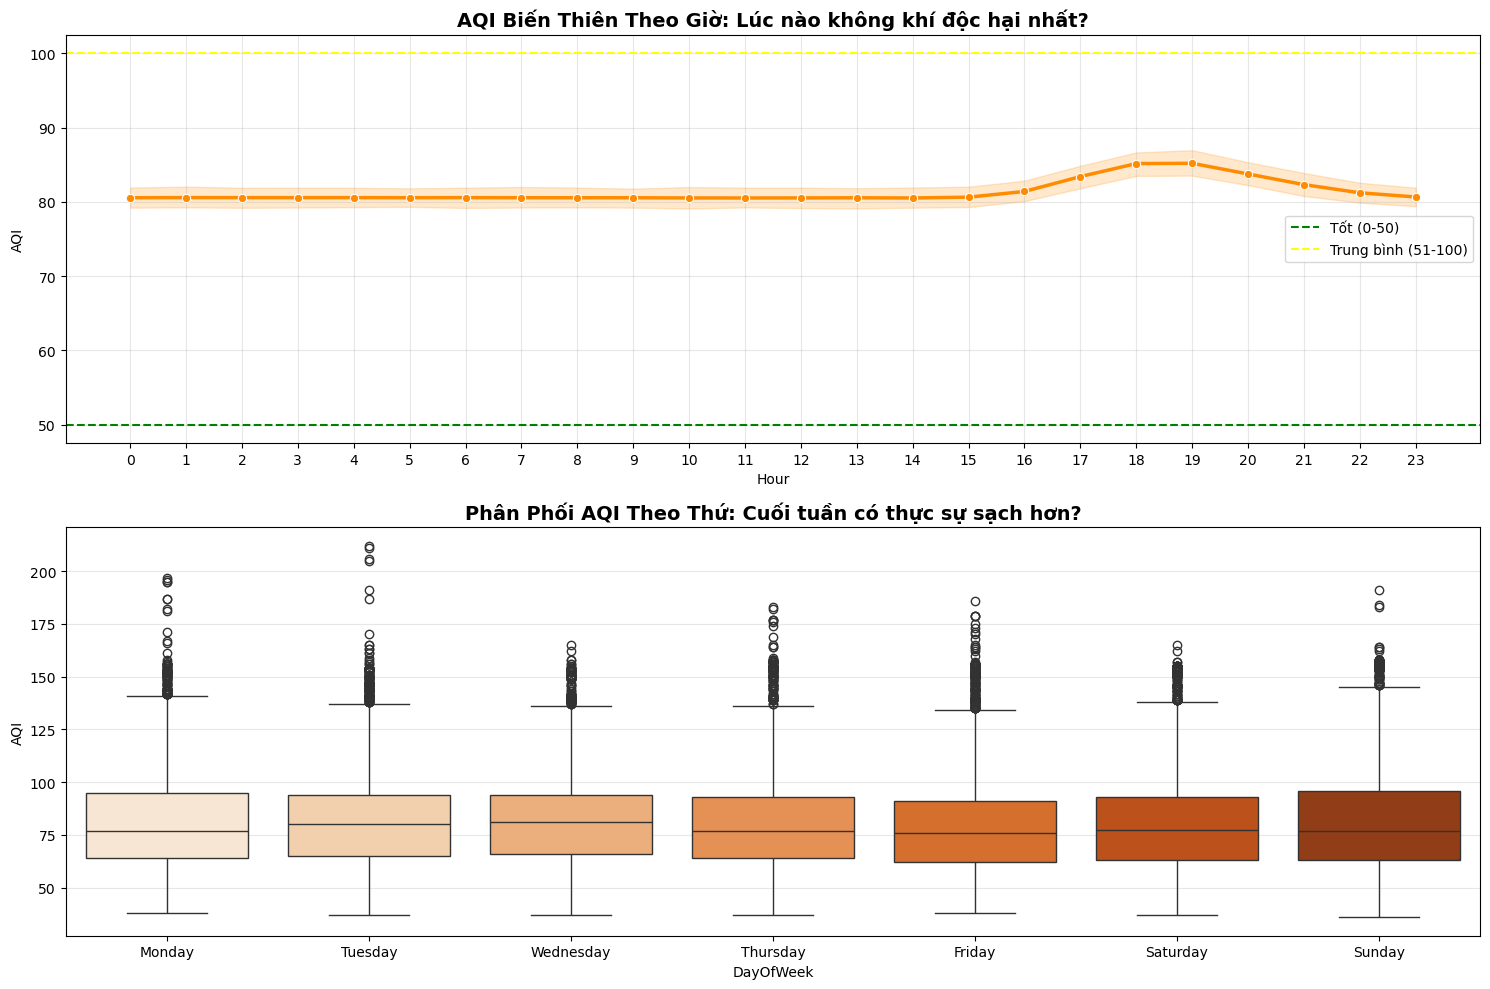

In [4]:
# 1. Đảm bảo cột Date chuẩn và tạo các cột thời gian
df['Date'] = pd.to_datetime(df['time'])
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(15, 10))

# --- BIỂU ĐỒ 1: AQI THEO GIỜ (Nhịp sinh hoạt) ---
plt.subplot(2, 1, 1)
sns.lineplot(x='Hour', y='AQI', data=df, marker='o', color='darkorange', linewidth=2.5)
plt.axhline(50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(100, color='yellow', linestyle='--', label='Trung bình (51-100)')
plt.title('AQI Biến Thiên Theo Giờ: Lúc nào không khí độc hại nhất?', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()

# --- BIỂU ĐỒ 2: AQI THEO THỨ (Quy luật tuần) ---
plt.subplot(2, 1, 2)
sns.boxplot(x='DayOfWeek', y='AQI', data=df, order=days_order, palette='Oranges')
plt.title('Phân Phối AQI Theo Thứ: Cuối tuần có thực sự sạch hơn?', fontsize=14, fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: 26880 giờ đo) ---
• PM2.5: ⚠️ NGUY HIỂM (Vượt 21366/26880 giờ) - Giới hạn: 15 µg/m³
• PM10: ⚠️ NGUY HIỂM (Vượt 5520/26880 giờ) - Giới hạn: 45 µg/m³
• NO2: ⚠️ NGUY HIỂM (Vượt 15192/26880 giờ) - Giới hạn: 25 µg/m³
• CO: ⚠️ NGUY HIỂM (Vượt 39/26880 giờ) - Giới hạn: 4000 µg/m³
• SO2: ⚠️ NGUY HIỂM (Vượt 2731/26880 giờ) - Giới hạn: 40 µg/m³
• O3: ⚠️ NGUY HIỂM (Vượt 4321/26880 giờ) - Giới hạn: 100 µg/m³


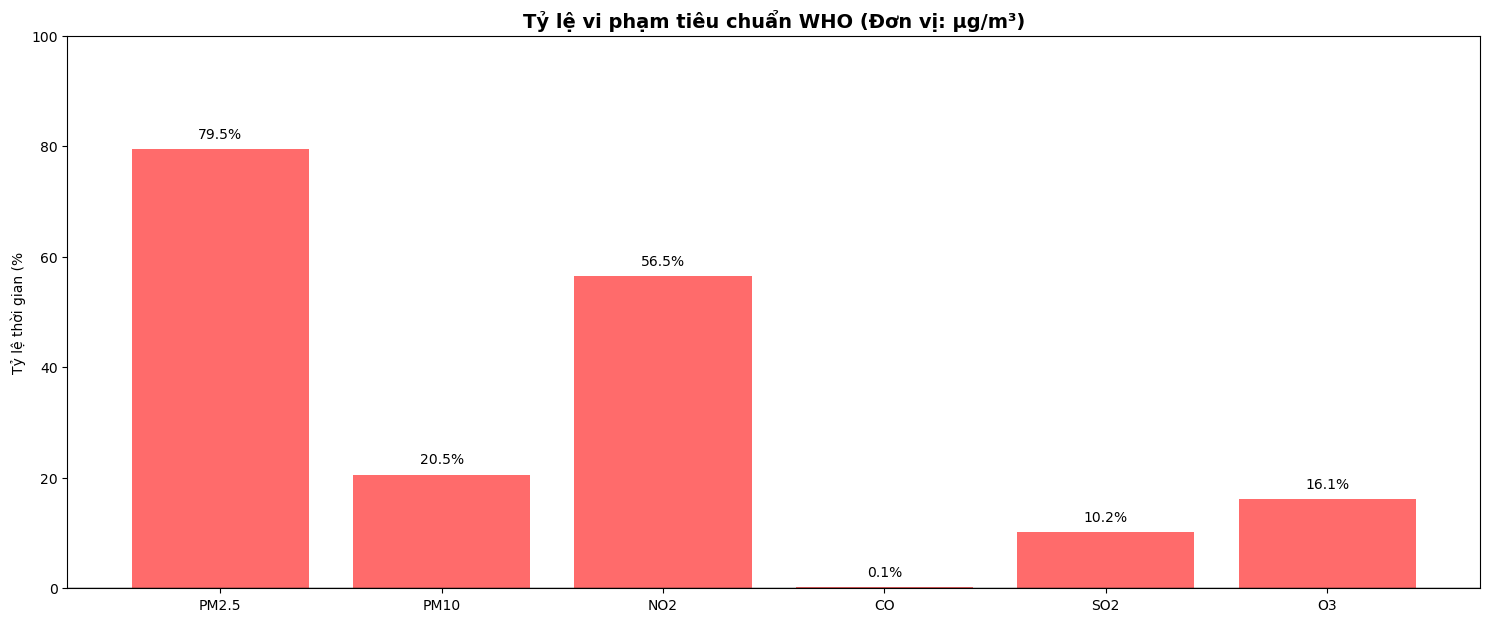

In [5]:
# ==============================================================================
# 1. THIẾT LẬP NGƯỠNG AN TOÀN THEO WHO (µg/m³)
# ==============================================================================
thresholds_who = {
    'PM2.5': 15,    
    'PM10':  45,    
    'NO2':   25,    
    'CO':    4000,  
    'SO2':   40,    
    'O3':    100    
}

# ==============================================================================
# 2. TÍNH TOÁN & IN KẾT QUẢ (SỐ GIỜ CỤ THỂ)
# ==============================================================================
results = {} # Lưu lại để vẽ biểu đồ
total_hours = len(df) # Tổng số dòng trong dataset

print(f"--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: {total_hours} giờ đo) ---")

for pollutant, limit in thresholds_who.items():
    if pollutant in df.columns:
        # Đếm số dòng vượt ngưỡng
        exceed_count = (df[pollutant] > limit).sum()
        
        # Tính phần trăm để lưu vào biểu đồ (vẫn cần % để vẽ cột cho đẹp)
        exceed_rate = (exceed_count / total_hours) * 100
        results[pollutant] = exceed_rate
        
        # In ra màn hình theo yêu cầu của bạn: Số lượng / Tổng số
        status = "⚠️ NGUY HIỂM" if exceed_count > 0 else "✅ AN TOÀN"
        
        # Format in ra: Ví dụ "Vượt 2500/8760 giờ"
        print(f"• {pollutant}: {status} (Vượt {exceed_count}/{total_hours} giờ) - Giới hạn: {limit} µg/m³")

# ==============================================================================
# 3. VẼ BIỂU ĐỒ (ĐÃ FIX LỖI WARNING)
# ==============================================================================
plt.figure(figsize=(15, 12)) # Tăng kích thước để vẽ 2 biểu đồ

# --- BIỂU ĐỒ 1: TỶ LỆ VI PHẠM ---
plt.subplot(2, 1, 1)
bars = plt.bar(results.keys(), results.values(), color=['#ff6b6b' if v > 0 else '#4ecdc4' for v in results.values()])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Tỷ lệ thời gian (%')
plt.title(f'Tỷ lệ vi phạm tiêu chuẩn WHO (Đơn vị: µg/m³)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{round(yval, 1)}%', ha='center')

plt.tight_layout()
plt.show()

--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: 26880 giờ đo) ---
• PM2.5: ⚠️ NGUY HIỂM (Vượt 21366/26880 giờ) - Giới hạn: 15 µg/m³
• PM10: ⚠️ NGUY HIỂM (Vượt 5520/26880 giờ) - Giới hạn: 45 µg/m³
• NO2: ⚠️ NGUY HIỂM (Vượt 15192/26880 giờ) - Giới hạn: 25 µg/m³
• CO: ⚠️ NGUY HIỂM (Vượt 39/26880 giờ) - Giới hạn: 4000 µg/m³
• SO2: ⚠️ NGUY HIỂM (Vượt 2731/26880 giờ) - Giới hạn: 40 µg/m³
• O3: ⚠️ NGUY HIỂM (Vượt 4321/26880 giờ) - Giới hạn: 100 µg/m³


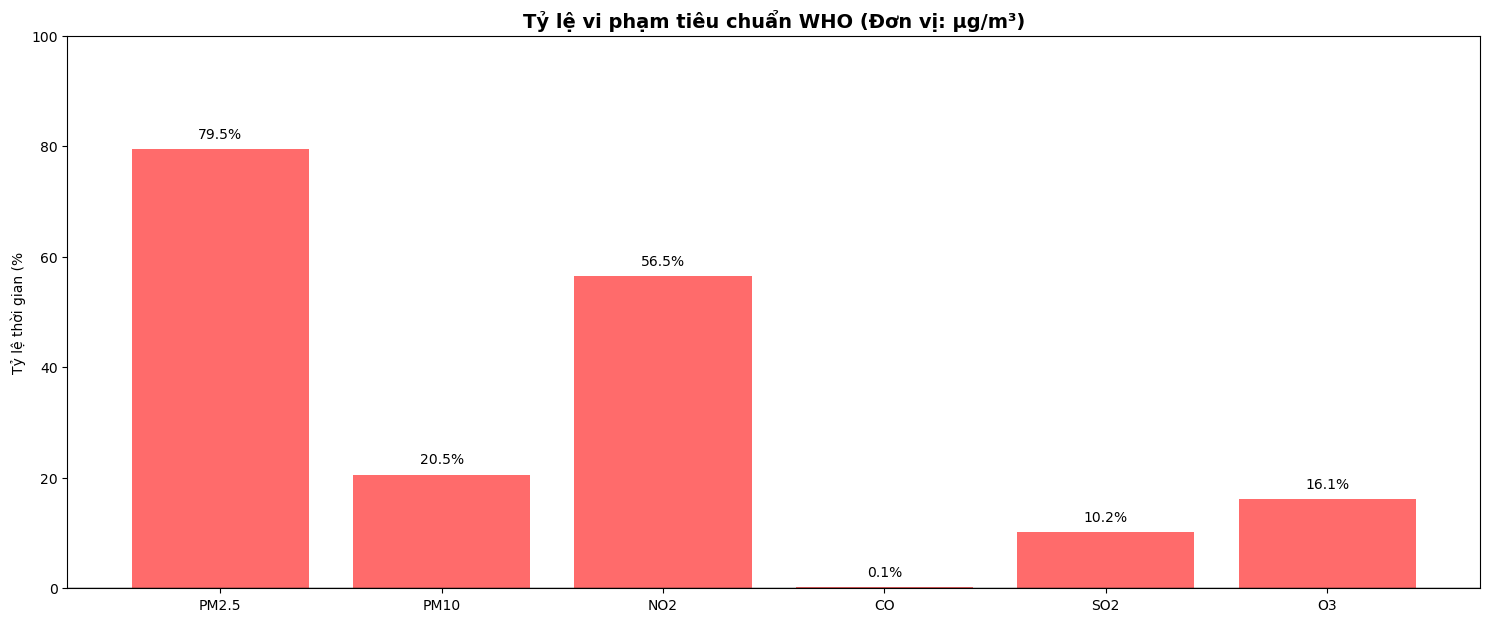

In [6]:
# ==============================================================================
# 1. THIẾT LẬP NGƯỠNG AN TOÀN THEO WHO (µg/m³)
# ==============================================================================
thresholds_who = {
    'PM2.5': 15,    
    'PM10':  45,    
    'NO2':   25,    
    'CO':    4000,  
    'SO2':   40,    
    'O3':    100    
}

# ==============================================================================
# 2. TÍNH TOÁN & IN KẾT QUẢ (SỐ GIỜ CỤ THỂ)
# ==============================================================================
results = {} # Lưu lại để vẽ biểu đồ
total_hours = len(df) # Tổng số dòng trong dataset

print(f"--- 🔍 KẾT QUẢ KIỂM TRA (Tổng cộng: {total_hours} giờ đo) ---")

for pollutant, limit in thresholds_who.items():
    if pollutant in df.columns:
        # Đếm số dòng vượt ngưỡng
        exceed_count = (df[pollutant] > limit).sum()
        
        # Tính phần trăm để lưu vào biểu đồ (vẫn cần % để vẽ cột cho đẹp)
        exceed_rate = (exceed_count / total_hours) * 100
        results[pollutant] = exceed_rate
        
        # In ra màn hình theo yêu cầu của bạn: Số lượng / Tổng số
        status = "⚠️ NGUY HIỂM" if exceed_count > 0 else "✅ AN TOÀN"
        
        # Format in ra: Ví dụ "Vượt 2500/8760 giờ"
        print(f"• {pollutant}: {status} (Vượt {exceed_count}/{total_hours} giờ) - Giới hạn: {limit} µg/m³")

# ==============================================================================
# 3. VẼ BIỂU ĐỒ (ĐÃ FIX LỖI WARNING)
# ==============================================================================
plt.figure(figsize=(15, 12)) # Tăng kích thước để vẽ 2 biểu đồ

# --- BIỂU ĐỒ 1: TỶ LỆ VI PHẠM ---
plt.subplot(2, 1, 1)
bars = plt.bar(results.keys(), results.values(), color=['#ff6b6b' if v > 0 else '#4ecdc4' for v in results.values()])
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Tỷ lệ thời gian (%')
plt.title(f'Tỷ lệ vi phạm tiêu chuẩn WHO (Đơn vị: µg/m³)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{round(yval, 1)}%', ha='center')



plt.tight_layout()
plt.show()

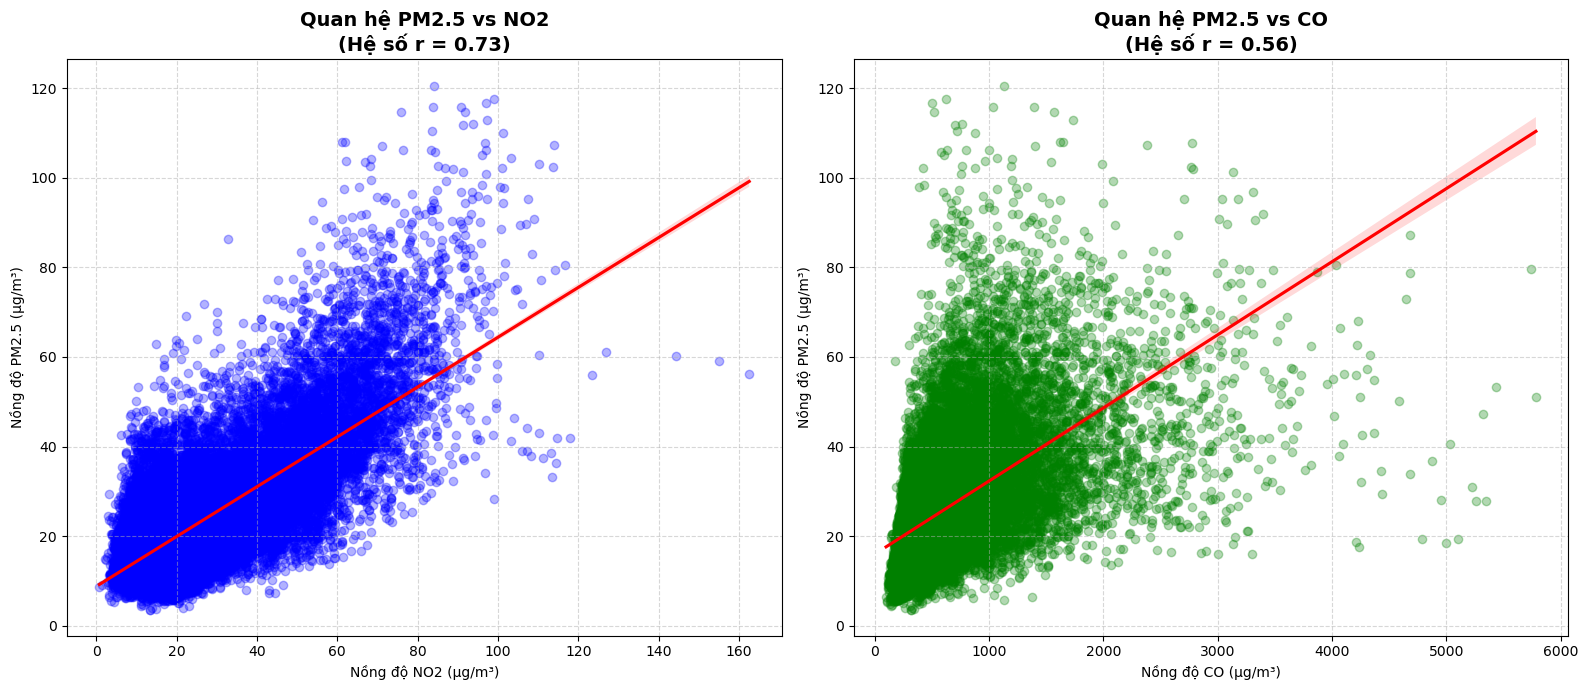

--------------------------------------------------
🕵️ KẾT LUẬN CỦA THÁM TỬ DỮ LIỆU:
🔴 NO2 (Xe tải/Bus) có quan hệ RẤT MẠNH với PM2.5 (r=0.73). -> CHẮC CHẮN do xe cộ.
🟠 CO (Xe con/Xăng) có quan hệ VỪA PHẢI với PM2.5 (r=0.56). -> Xe cộ đóng góp một phần lớn.
--------------------------------------------------


In [7]:
# ==============================================================================
# 1. TÍNH TOÁN HỆ SỐ TƯƠNG QUAN (Correlation Coefficient - r)
# ==============================================================================
# r chạy từ -1 đến 1. 
# r càng gần 1: Hai chất này là "bạn thân" (Cùng tăng cùng giảm)
corr_no2 = df['PM2.5'].corr(df['NO2'])
corr_co = df['PM2.5'].corr(df['CO'])

# ==============================================================================
# 2. VẼ BIỂU ĐỒ SCATTER (BIỂU ĐỒ PHÂN TÁN)
# ==============================================================================
plt.figure(figsize=(16, 7))

# --- BIỂU ĐỒ 1: PM2.5 vs NO2 (Đại diện xe chạy dầu/xe tải) ---
plt.subplot(1, 2, 1)
# regplot sẽ vẽ thêm 1 đường hồi quy (đường xu hướng) để dễ nhìn
sns.regplot(x='NO2', y='PM2.5', data=df, 
            scatter_kws={'alpha':0.3, 'color':'blue'}, # Chấm mờ để thấy mật độ
            line_kws={'color':'red'}) # Đường xu hướng màu đỏ

plt.title(f'Quan hệ PM2.5 vs NO2\n(Hệ số r = {corr_no2:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Nồng độ NO2 (µg/m³)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: PM2.5 vs CO (Đại diện xe chạy xăng/xe con) ---
plt.subplot(1, 2, 2)
sns.regplot(x='CO', y='PM2.5', data=df, 
            scatter_kws={'alpha':0.3, 'color':'green'}, 
            line_kws={'color':'red'})

plt.title(f'Quan hệ PM2.5 vs CO\n(Hệ số r = {corr_co:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Nồng độ CO (µg/m³)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. MÁY TÍNH TỰ ĐỘNG KẾT LUẬN
# ==============================================================================
print("-" * 50)
print("🕵️ KẾT LUẬN CỦA THÁM TỬ DỮ LIỆU:")

def phan_tich_tuong_quan(name, r):
    if r > 0.7:
        return f"🔴 {name} có quan hệ RẤT MẠNH với PM2.5 (r={r:.2f}). -> CHẮC CHẮN do xe cộ."
    elif r > 0.4:
        return f"🟠 {name} có quan hệ VỪA PHẢI với PM2.5 (r={r:.2f}). -> Xe cộ đóng góp một phần lớn."
    elif r > 0:
        return f"🟡 {name} có quan hệ YẾU với PM2.5 (r={r:.2f}). -> Có thể do bụi xây dựng hoặc nguồn khác."
    else:
        return f"🟢 {name} đi NGƯỢC CHIỀU với PM2.5 (r={r:.2f}). -> Không phải nguyên nhân."

print(phan_tich_tuong_quan("NO2 (Xe tải/Bus)", corr_no2))
print(phan_tich_tuong_quan("CO (Xe con/Xăng)", corr_co))
print("-" * 50)

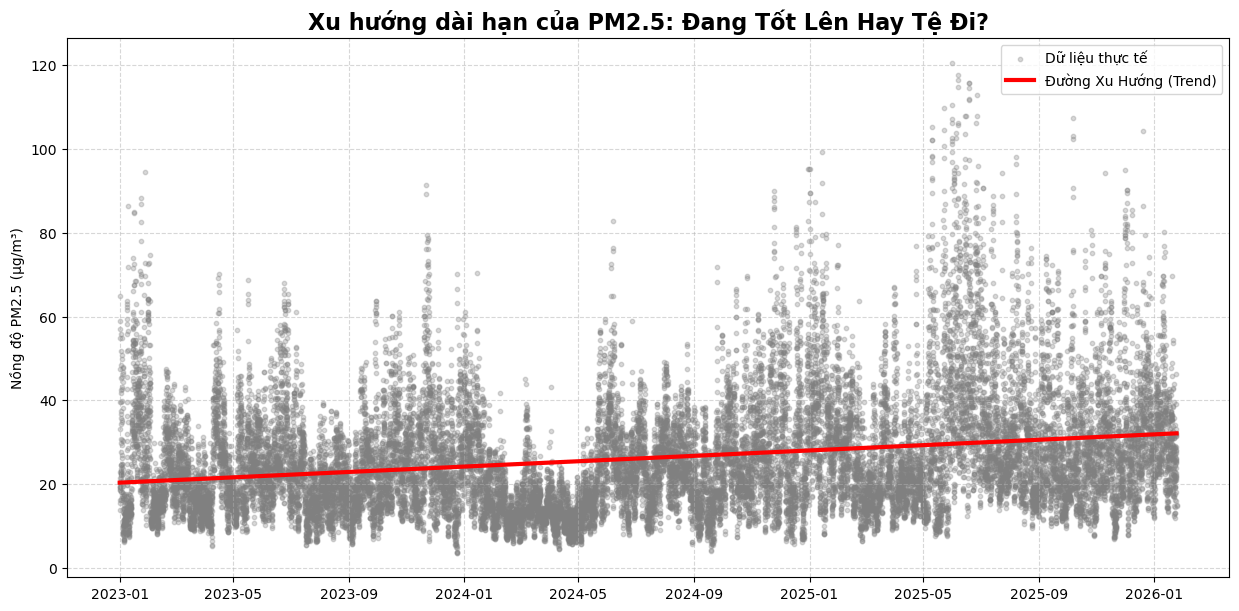

------------------------------------------------------------
📊 KẾT QUẢ PHÂN TÍCH XU HƯỚNG (PM2.5):
• Độ dốc (Slope): 0.0105 (µg/m³ mỗi ngày)
• Độ tin cậy (P-value): 0.00000
------------------------------------------------------------
🔴 KẾT LUẬN: TỆ ĐI! Ô nhiễm đang có xu hướng TĂNG theo thời gian.
   (Trung bình mỗi ngày tăng thêm 0.0105 µg/m³)
------------------------------------------------------------


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ==============================================================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==============================================================================
# Chọn biến cần soi (Ví dụ: PM2.5 hoặc NO2)
target = 'PM2.5' 

# Chuyển đổi ngày tháng sang dạng số (Ordinal) để máy tính tính toán được
# Ví dụ: Ngày 1 -> 738000, Ngày 2 -> 738001...
df['Date_Ordinal'] = pd.to_datetime(df['Date']).map(pd.Timestamp.toordinal)

# ==============================================================================
# 2. TÍNH TOÁN HỒI QUY TUYẾN TÍNH (LINEAR REGRESSION)
# ==============================================================================
# Hàm này sẽ tìm ra đường thẳng y = ax + b phù hợp nhất
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Date_Ordinal'], df[target])

# slope (Hệ số góc): Quan trọng nhất! Nó cho biết độ dốc của đường.
# p_value: Độ tin cậy. Nếu p < 0.05 nghĩa là xu hướng này là THẬT, không phải ngẫu nhiên.

# ==============================================================================
# 3. VẼ BIỂU ĐỒ TREND
# ==============================================================================
plt.figure(figsize=(15, 7))

# Vẽ dữ liệu thực tế (Mờ đi để làm nền)
plt.scatter(df['Date'], df[target], color='gray', alpha=0.3, s=10, label='Dữ liệu thực tế')

# Vẽ đường Trend (Tính toán từ phương trình y = ax + b)
y_pred = slope * df['Date_Ordinal'] + intercept
color_trend = 'red' if slope > 0 else 'green' # Đỏ nếu tăng, Xanh nếu giảm
plt.plot(df['Date'], y_pred, color=color_trend, linewidth=3, label=f'Đường Xu Hướng (Trend)')

plt.title(f'Xu hướng dài hạn của {target}: Đang Tốt Lên Hay Tệ Đi?', fontsize=16, fontweight='bold')
plt.ylabel(f'Nồng độ {target} (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# ==============================================================================
# 4. KẾT LUẬN TỰ ĐỘNG
# ==============================================================================
print("-" * 60)
print(f"📊 KẾT QUẢ PHÂN TÍCH XU HƯỚNG ({target}):")
print(f"• Độ dốc (Slope): {slope:.4f} (µg/m³ mỗi ngày)")
print(f"• Độ tin cậy (P-value): {p_value:.5f}")
print("-" * 60)

if p_value > 0.05:
    print("👉 KẾT LUẬN: Không có xu hướng rõ ràng (Dữ liệu đi ngang hoặc biến động ngẫu nhiên).")
elif slope > 0:
    print("🔴 KẾT LUẬN: TỆ ĐI! Ô nhiễm đang có xu hướng TĂNG theo thời gian.")
    print(f"   (Trung bình mỗi ngày tăng thêm {slope:.4f} µg/m³)")
else:
    print("🟢 KẾT LUẬN: TỐT LÊN! Ô nhiễm đang có xu hướng GIẢM.")
    print(f"   (Trung bình mỗi ngày giảm được {abs(slope):.4f} µg/m³)")
print("-" * 60)

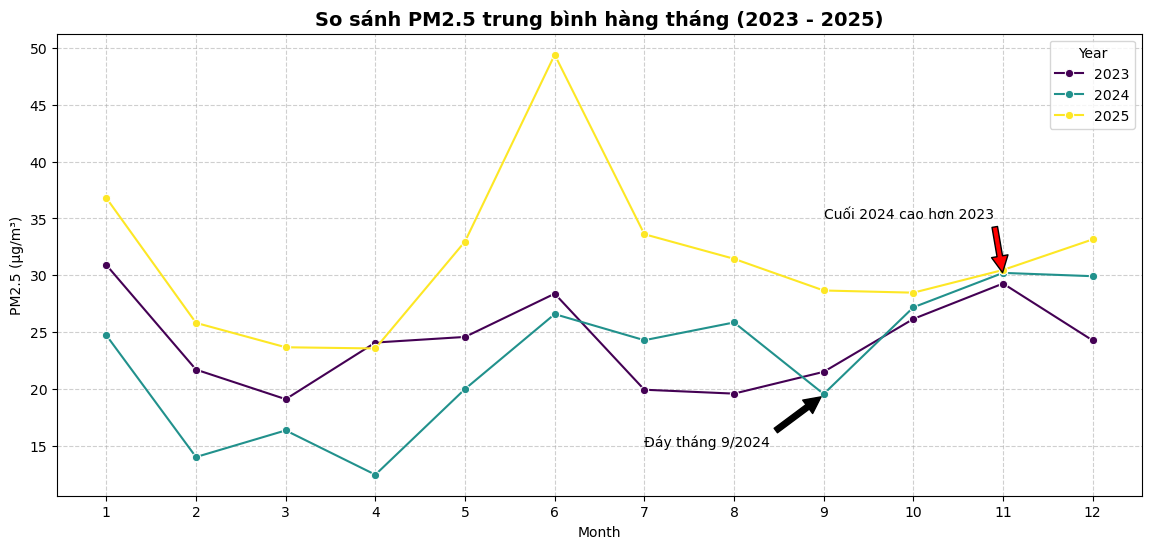

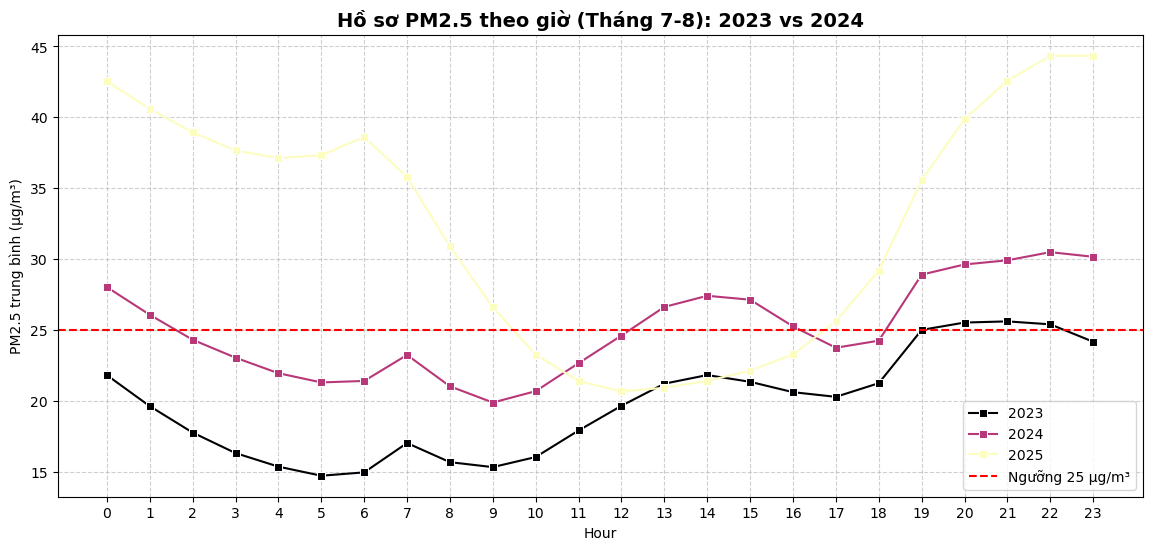

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['time'] = pd.to_datetime(df['time']) 

# Tạo thêm các cột mới để lọc dữ liệu
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df['Hour'] = df['time'].dt.hour

# 3. Bây giờ mới lọc dữ liệu theo năm (sẽ không còn lỗi KeyError 'Year' nữa)
df_filtered = df[df['Year'].isin([2023, 2024, 2025])]

# 4. Vẽ biểu đồ so sánh hàng tháng
monthly_avg = df_filtered.groupby(['Year', 'Month'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg, x='Month', y='PM2.5', hue='Year', marker='o', palette='viridis')

# Thêm ghi chú cho các quan sát của bạn
plt.annotate('Đáy tháng 9/2024', xy=(9, 19.5), xytext=(7, 15),arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Cuối 2024 cao hơn 2023', xy=(11, 30), xytext=(9, 35),arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('So sánh PM2.5 trung bình hàng tháng (2023 - 2025)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13))
plt.ylabel('PM2.5 (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Vẽ hồ sơ theo giờ cho tháng 7-8 để kiểm tra "Đỉnh đêm"
jul_aug_data = df_filtered[df_filtered['Month'].isin([7, 8])]
diurnal_jul_aug = jul_aug_data.groupby(['Year', 'Hour'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=diurnal_jul_aug, x='Hour', y='PM2.5', hue='Year', marker='s', palette='magma')
plt.axhline(y=25, color='red', linestyle='--', label='Ngưỡng 25 µg/m³')

plt.title('Hồ sơ PM2.5 theo giờ (Tháng 7-8): 2023 vs 2024', fontsize=14, fontweight='bold')
plt.xticks(range(0, 24))
plt.ylabel('PM2.5 trung bình (µg/m³)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

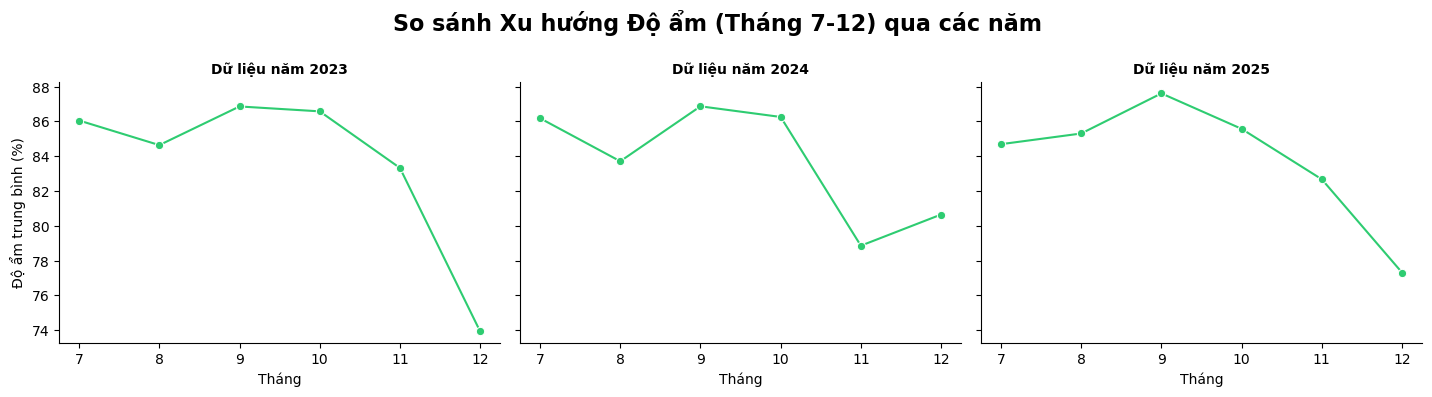

In [13]:
# 2. Lọc dữ liệu từ tháng 7-12 cho 3 năm 2023, 2024, 2025
mask = (df['Month'] >= 7) & (df['Month'] <= 12) & (df['Year'].isin([2023, 2024, 2025]))
df_filtered = df[mask].copy()

# 3. Tính trung bình độ ẩm hàng tháng
humidity_avg = df_filtered.groupby(['Year', 'Month'])['Humidity'].mean().reset_index()

# 4. Vẽ kiểu FacetGrid (nhiều biểu đồ nhỏ cạnh nhau)
# col="Year" có nghĩa là mỗi năm sẽ được vẽ trên 1 cột riêng
# height và aspect dùng để điều chỉnh kích thước của mỗi hình nhỏ
g = sns.FacetGrid(humidity_avg, col="Year", height=4, aspect=1.2, sharey=True)

# Dùng sns.lineplot để vẽ đường cho từng ô
g.map(sns.lineplot, "Month", "Humidity", marker="o", color="#2ecc71")

# 5. Tinh chỉnh tiêu đề và trục
g.set_axis_labels("Tháng", "Độ ẩm trung bình (%)")
g.set_titles("Dữ liệu năm {col_name}", fontweight='bold')
g.set(xticks=range(7, 13))

# Thêm tiêu đề tổng thể cho cả cụm biểu đồ
plt.subplots_adjust(top=0.8)
g.fig.suptitle('So sánh Xu hướng Độ ẩm (Tháng 7-12) qua các năm', fontsize=16, fontweight='bold')

plt.show()

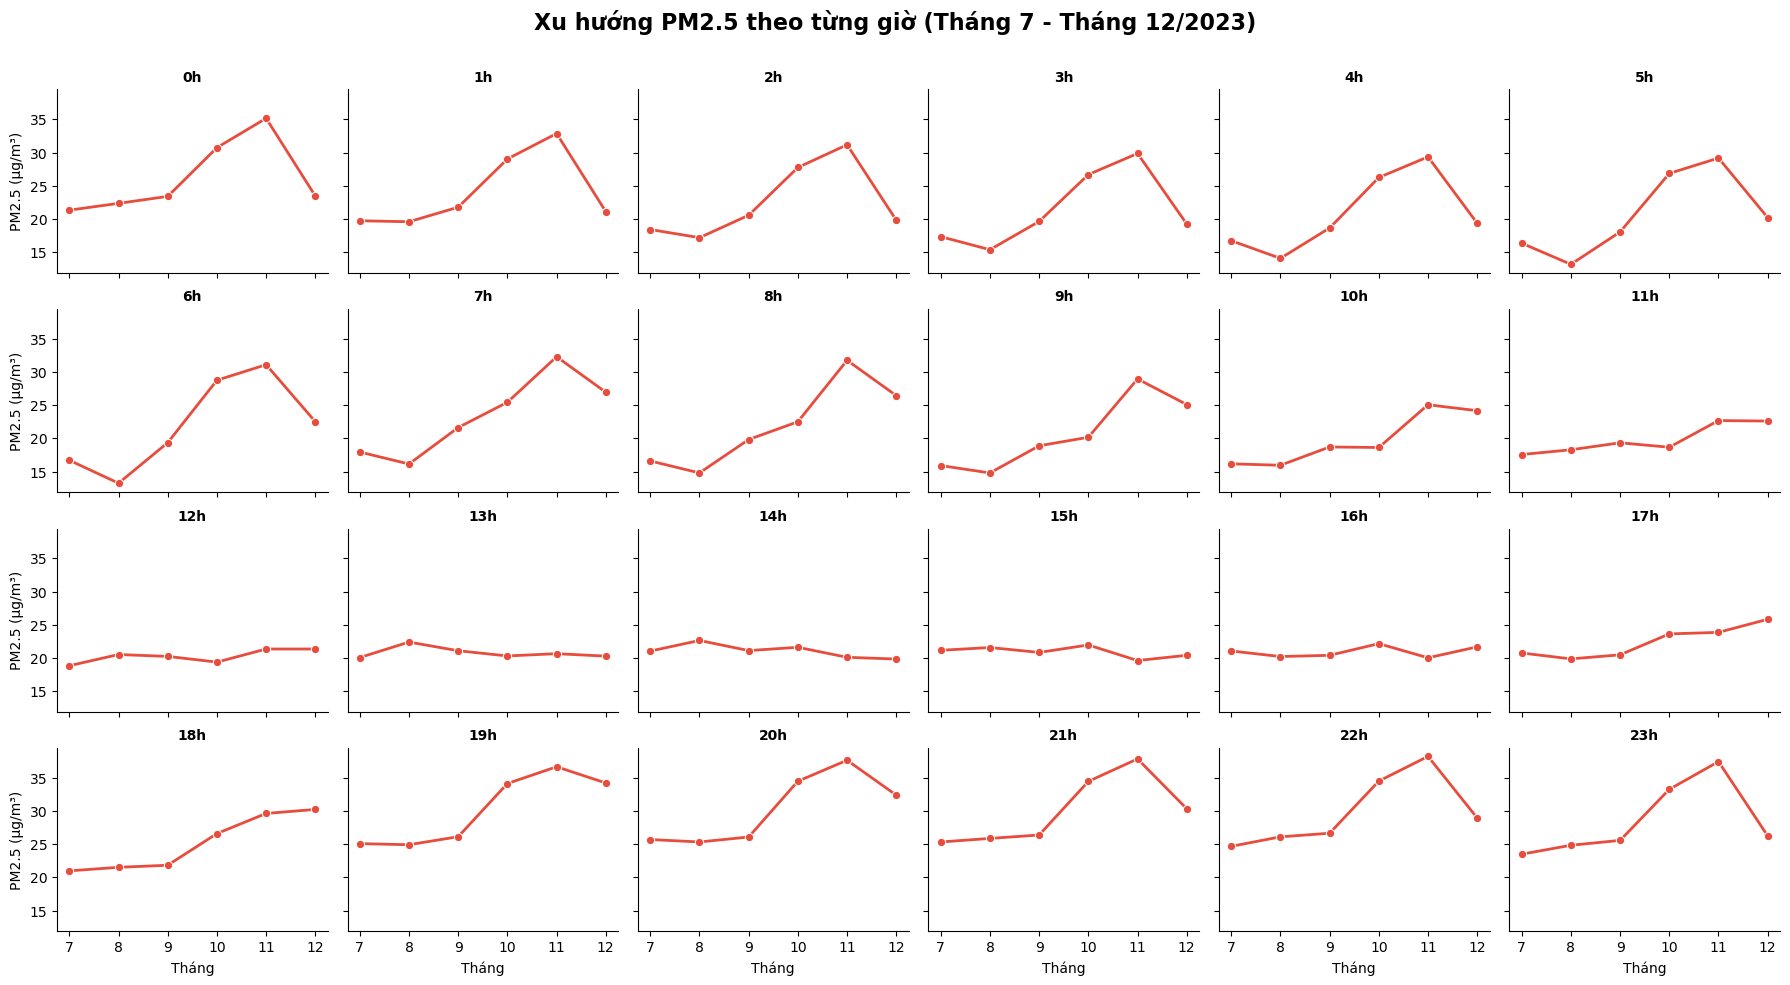

In [14]:
mask = (df['Year'] == 2023) & (df['Month'] >= 7) & (df['Month'] <= 12)
df_filtered = df[mask]

# 3. Tính trung bình PM2.5 theo từng Tháng và từng Giờ
hourly_monthly_avg = df_filtered.groupby(['Hour', 'Month'])['PM2.5'].mean().reset_index()

# 4. Vẽ 24 biểu đồ nhỏ (FacetGrid)
# col_wrap=6 nghĩa là mỗi hàng sẽ có 6 biểu đồ (tổng cộng 4 hàng x 6 cột = 24 ô)
g = sns.FacetGrid(hourly_monthly_avg, col="Hour", col_wrap=6, height=2.5, aspect=1.2, sharey=True)

# Dùng sns.lineplot để vẽ đường nối các tháng trong từng ô
g.map(sns.lineplot, "Month", "PM2.5", marker="o", color="#e74c3c", linewidth=2)

# Tinh chỉnh giao diện cho đẹp
g.set_axis_labels("Tháng", "PM2.5 (µg/m³)")
g.set_titles("{col_name}h", fontweight='bold')
g.set(xticks=range(7, 13))

# Thêm tiêu đề tổng thể cho nguyên cụm
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Xu hướng PM2.5 theo từng giờ (Tháng 7 - Tháng 12/2023)', fontsize=16, fontweight='bold')

plt.show()

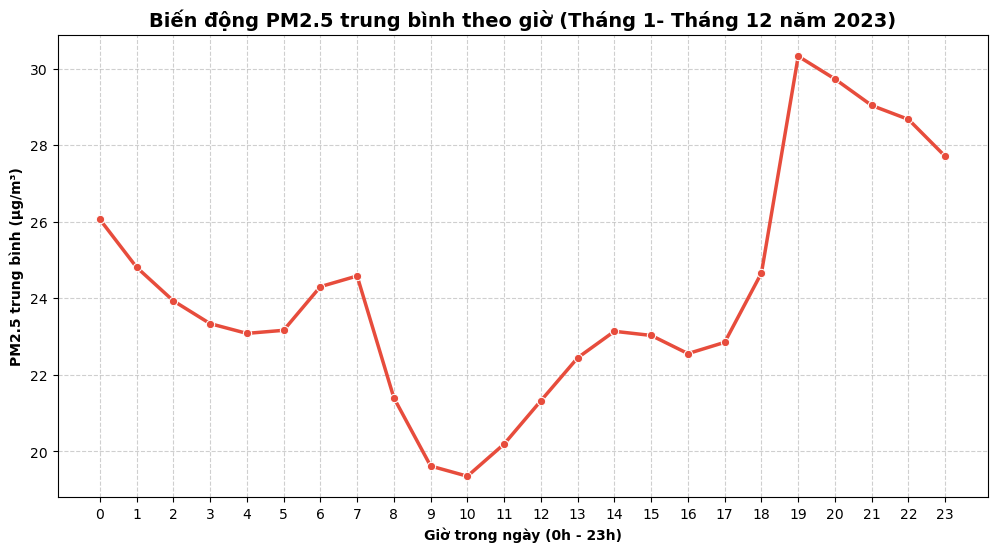

In [16]:
mask = (df['Year'] == 2023) & (df['Month'] >= 0) & (df['Month'] <= 12)
df_filtered = df[mask]

# 3. Tính giá trị trung bình PM2.5 cho từng giờ
hourly_avg = df_filtered.groupby('Hour')['PM2.5'].mean().reset_index()

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_avg, x='Hour', y='PM2.5', marker='o', color='#e74c3c', linewidth=2.5)

# Cấu hình trục và tiêu đề
plt.title('Biến động PM2.5 trung bình theo giờ (Tháng 1- Tháng 12 năm 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0h - 23h)', fontweight='bold')
plt.ylabel('PM2.5 trung bình (µg/m³)', fontweight='bold')

# Cấu hình cho trục X hiển thị đủ từ 0 đến 23
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

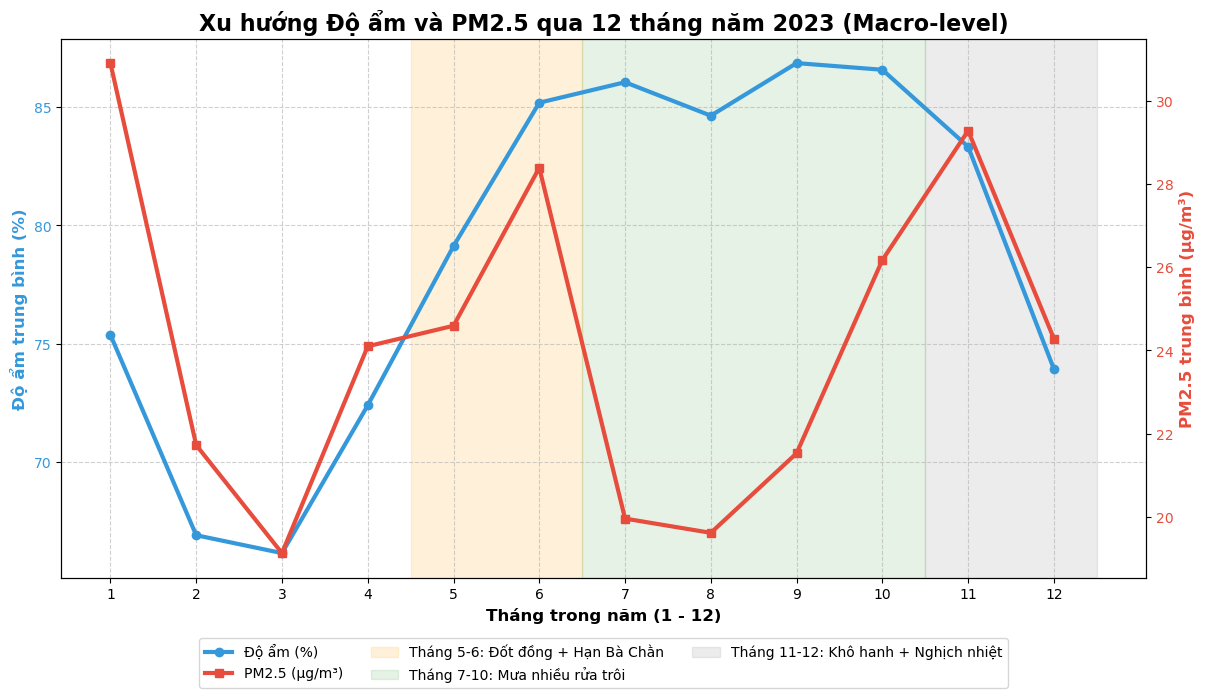

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Đảm bảo dữ liệu thời gian chuẩn xác và lọc riêng năm 2023
df['time'] = pd.to_datetime(df['time'])
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df_2023 = df[df['Year'] == 2023]

# 2. Tính trung bình PM2.5 và Độ ẩm cho 12 tháng
monthly_trend = df_2023.groupby('Month')[['Humidity', 'PM2.5']].mean().reset_index()

# 3. Vẽ biểu đồ 2 trục (Dual-axis)
fig, ax1 = plt.subplots(figsize=(14, 7))

# Trục Y 1: Độ ẩm (Màu xanh dương)
color1 = '#3498db'
ax1.set_xlabel('Tháng trong năm (1 - 12)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Độ ẩm trung bình (%)', color=color1, fontweight='bold', fontsize=12)
line1 = ax1.plot(monthly_trend['Month'], monthly_trend['Humidity'], color=color1, marker='o', linewidth=3, label='Độ ẩm (%)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(1, 13))

# Trục Y 2: PM2.5 (Màu đỏ)
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('PM2.5 trung bình (µg/m³)', color=color2, fontweight='bold', fontsize=12)
line2 = ax2.plot(monthly_trend['Month'], monthly_trend['PM2.5'], color=color2, marker='s', linewidth=3, label='PM2.5 (µg/m³)')
ax2.tick_params(axis='y', labelcolor=color2)

# 4. Thêm nền màu Highlight để chứng minh các pha trong năm
# Highlight Pha 1: Đỉnh ô nhiễm giữa năm (Tháng 5 - 6) -> PM2.5 tăng
ax1.axvspan(4.5, 6.5, color='orange', alpha=0.15)
# Highlight Pha 2: Mùa mưa rửa trôi (Tháng 7 - 10) -> Độ ẩm cao, PM2.5 chạm đáy
ax1.axvspan(6.5, 10.5, color='green', alpha=0.1)
# Highlight Pha 3: Chuyển mùa cuối năm (Tháng 11 - 12) -> Độ ẩm cắm đầu, PM2.5 tăng vọt
ax1.axvspan(10.5, 12.5, color='gray', alpha=0.15)

# 5. Cấu hình tiêu đề và chú thích (Legend)
plt.title('Xu hướng Độ ẩm và PM2.5 qua 12 tháng năm 2023 (Macro-level)', fontsize=16, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

# Tạo thủ công các chú thích màu sắc
orange_patch = mpatches.Patch(color='orange', alpha=0.15, label='Tháng 5-6: Đốt đồng + Hạn Bà Chằn')
green_patch = mpatches.Patch(color='green', alpha=0.1, label='Tháng 7-10: Mưa nhiều rửa trôi')
gray_patch = mpatches.Patch(color='gray', alpha=0.15, label='Tháng 11-12: Khô hanh + Nghịch nhiệt')

# Gộp chú thích và dàn hàng ngang cho đẹp
ax1.legend(handles=[line1[0], line2[0], orange_patch, green_patch, gray_patch], 
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

plt.show()

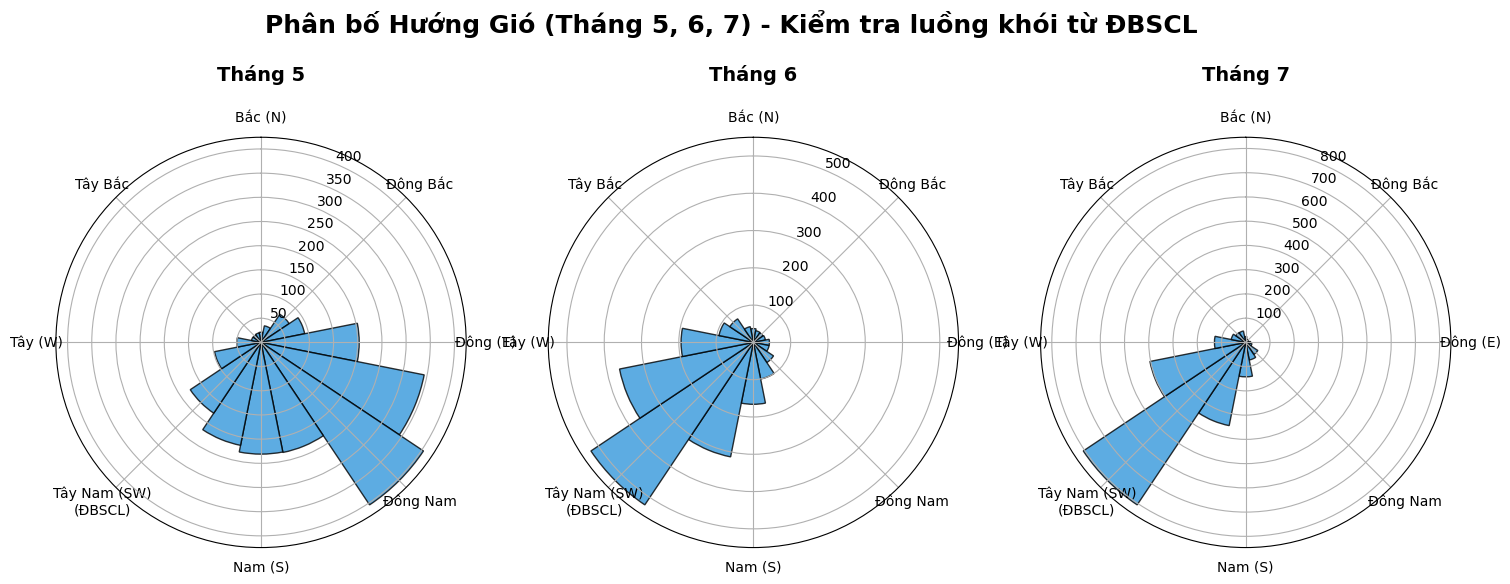

In [20]:

fig, axes = plt.subplots(1, 3, subplot_kw={'projection': 'polar'}, figsize=(18, 6))
months = [5, 6, 7]
month_names = ['Tháng 5', 'Tháng 6', 'Tháng 7']

for i, month in enumerate(months):
    # Lấy dữ liệu hướng gió của tháng
    data = df[df['Month'] == month]['Wind_Dir']
    
    # Chia 360 độ thành 16 hướng gió (mỗi hướng 22.5 độ)
    bins = np.linspace(0, 360, 17)
    hist, _ = np.histogram(data, bins=bins)
    
    # Tính toán góc cho đồ thị bằng radian
    theta = np.deg2rad(bins[:-1])
    width = np.deg2rad(22.5)
    
    ax = axes[i]
    # Vẽ cột
    bars = ax.bar(theta, hist, width=width, bottom=0.0, alpha=0.8, color='#3498db', edgecolor='black')
    
    # Cấu hình la bàn (0 độ ở Bắc, quay theo chiều kim đồng hồ)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) 
    
    # Nhãn 8 hướng
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['Bắc (N)', 'Đông Bắc', 'Đông (E)', 'Đông Nam', 
                        'Nam (S)', 'Tây Nam (SW)\n(ĐBSCL)', 'Tây (W)', 'Tây Bắc'])
    ax.set_title(f'{month_names[i]}\n', fontweight='bold', fontsize=14)

plt.suptitle('Phân bố Hướng Gió (Tháng 5, 6, 7) - Kiểm tra luồng khói từ ĐBSCL', fontsize=18, fontweight='bold', y=1.05)
plt.show()

<function matplotlib.pyplot.suptitle(t: 'str', **kwargs) -> 'Text'>

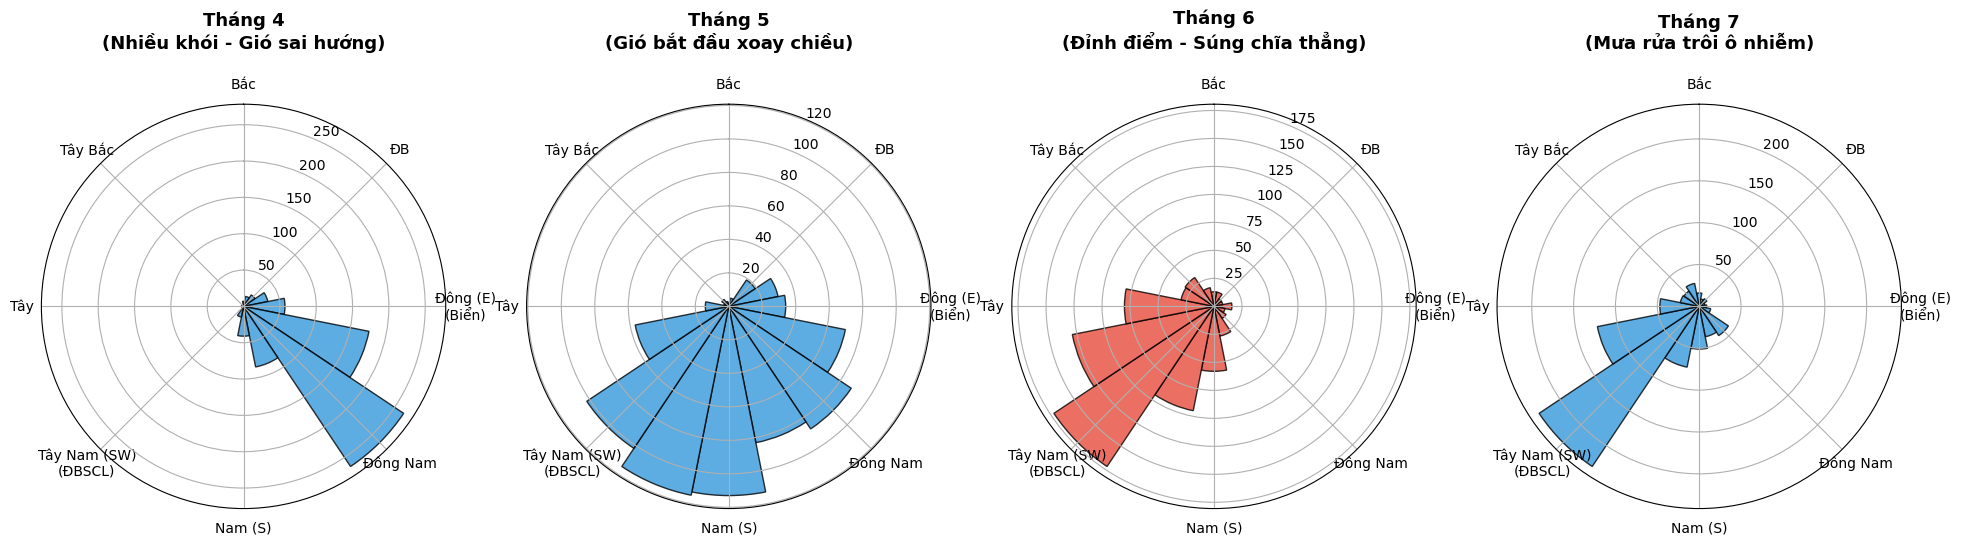

In [21]:

df['time'] = pd.to_datetime(df['time'])
df_2023 = df[df['time'].dt.year == 2023]

# 2. Tạo hình với 4 biểu đồ tròn (Polar plot)
fig, axes = plt.subplots(1, 4, subplot_kw={'projection': 'polar'}, figsize=(24, 6))
months = [4, 5, 6, 7]
month_names = ['Tháng 4\n(Nhiều khói - Gió sai hướng)', 
               'Tháng 5\n(Gió bắt đầu xoay chiều)', 
               'Tháng 6\n(Đỉnh điểm - Súng chĩa thẳng)', 
               'Tháng 7\n(Mưa rửa trôi ô nhiễm)']

for i, month in enumerate(months):
    # Lấy dữ liệu hướng gió của tháng tương ứng
    data = df_2023[df_2023['time'].dt.month == month]['Wind_Dir'].dropna()
    
    # Chia 360 độ thành 16 hướng
    bins = np.linspace(0, 360, 17)
    hist, _ = np.histogram(data, bins=bins)
    
    # Tính toán góc cho đồ thị (radian)
    theta = np.deg2rad(bins[:-1])
    width = np.deg2rad(22.5)
    
    ax = axes[i]
    # Highlight màu đỏ cho tháng 6 để nhấn mạnh đỉnh điểm
    color = '#e74c3c' if month == 6 else '#3498db'
    bars = ax.bar(theta, hist, width=width, bottom=0.0, alpha=0.8, color=color, edgecolor='black')
    
    # Cấu hình la bàn: Số 0 (Bắc) ở trên cùng
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) 
    
    # Nhãn la bàn có ghi chú rõ hướng Biển và hướng miền Tây
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['Bắc', 'ĐB', 'Đông (E)\n(Biển)', 'Đông Nam', 
                        'Nam (S)', 'Tây Nam (SW)\n(ĐBSCL)', 'Tây', 'Tây Bắc'])
    
    ax.set_title(f'{month_names[i]}\n', fontweight='bold', fontsize=13)

plt.suptitle

In [1]:
import pandas as pd
import json
import os
file_name = "hcm_aqi_full_dataset.csv"
file_name_new = "hcm_aqi_dataset.json"
folder_path = "dataset"
file_path = os.path.join(folder_path, file_name)
file_path_new = os.path.join(folder_path, file_name_new)
df = pd.read_csv(file_path)

# 2. Chuyển cột time sang định dạng datetime để lọc năm dễ dàng
import pandas as pd
import json
import os

output_path = file_path_new

df = pd.read_csv(file_path)

# 1. Chuyển time sang datetime
df['time'] = pd.to_datetime(df['time'])

# 2. TẠO CỘT THÁNG (Định dạng Năm-Tháng: YYYY-MM)
df['Month'] = df['time'].dt.strftime('%Y-%m')

# 3. Lọc lấy dữ liệu từ năm 2023 đến 2025
df_filtered = df[(df['time'].dt.year >= 2023) & (df['time'].dt.year <= 2025)]

# 4. ĐỔI 'Year' THÀNH 'Month' ở danh sách cột
columns_to_keep = ['Month', 'PM2.5', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'AQI']
df_final = df_filtered[columns_to_keep]

# 5. Gom nhóm theo THÁNG thay vì theo Năm
df_race = df_final.groupby('Month').mean().reset_index()

# 6. Xuất ra JSON
header = df_race.columns.tolist()
data_json = [header] + df_race.values.tolist()

os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(data_json, f, ensure_ascii=False)

print(f"✅ Đã tạo file dữ liệu THEO THÁNG thành công tại: {output_path}")

✅ Đã tạo file dữ liệu THEO THÁNG thành công tại: dataset\hcm_aqi_dataset.json


In [5]:
import pandas as pd
import json
import os
file_name = "hcm_aqi_full_dataset.csv"
file_name_new = "hcm_wind_dataset.json"
folder_path = "dataset"
file_path = os.path.join(folder_path, file_name)
file_path_new = os.path.join(folder_path, file_name_new)
df = pd.read_csv(file_path)

df['time'] = pd.to_datetime(df['time'])
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month

# 2. Xử lý Hướng Gió (0-360 -> 16 hướng)
# Mảng 16 hướng gió đã được Việt hóa (Trộn giữa ghi chú đầy đủ và viết tắt cho gọn)
directions = [
    'Bắc', 'BĐB', 'Đông Bắc', 'ĐĐB', 
    'Đông', 'ĐĐN', 'Đông Nam', 'NĐN', 
    'Nam', 'NTN', 'Tây Nam', 'TTN', 
    'Tây', 'TTB', 'Tây Bắc', 'BTB'
]
df['Dir_Index'] = ((df['Wind_Dir'] + 11.25) / 22.5).astype(int) % 16
df['Compass_Dir'] = df['Dir_Index'].apply(lambda x: directions[x])

# 3. Phân loại Tốc Độ Gió
bins = [-1, 2, 4, 6, 100] 
labels = ['Gió nhẹ (<2)', 'Gió vừa (2-4)', 'Gió mạnh (4-6)', 'Bão (>6)']
df['Speed_Cat'] = pd.cut(df['Wind_Speed'], bins=bins, labels=labels)

# 4. MA TRẬN MỤC TIÊU: Tháng 1, 6, 12 của các năm 2023, 2024, 2025
target_months = [1, 6, 12]
target_years = [2023, 2024, 2025]

grid_data = {}

for month in target_months:
    for year in target_years:
        # Lọc dữ liệu cho ô cụ thể này
        sub_df = df[(df['Month'] == month) & (df['Year'] == year)]
        
        # Key định danh để lát JS gọi, ví dụ: "m1_y2023"
        key = f"m{month}_y{year}"
        
        if sub_df.empty:
            grid_data[key] = None
        else:
            # Tính toán thống kê
            stats = sub_df.groupby(['Compass_Dir', 'Speed_Cat']).size().unstack(fill_value=0)
            stats = stats.reindex(directions).fillna(0) # Đảm bảo đủ 16 hướng
            
            grid_data[key] = {
                "series_data": [stats[label].tolist() for label in labels],
                "total_count": int(len(sub_df)) # Để hiển thị tổng số mẫu quan sát
            }

# Gói chung lại
final_export = {
    "directions": directions,
    "legend": labels,
    "grid": grid_data
}

# 5. Xuất file JSON
output_path = file_path_new
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(final_export, f, ensure_ascii=False)

print(f"✅ Đã tạo dữ liệu Ma trận Hoa Gió tại: {output_path}")

✅ Đã tạo dữ liệu Ma trận Hoa Gió tại: dataset\hcm_wind_dataset.json


C:\Users\nguye\AppData\Local\Temp\ipykernel_48860\1441129138.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = sub_df.groupby(['Compass_Dir', 'Speed_Cat']).size().unstack(fill_value=0)
C:\Users\nguye\AppData\Local\Temp\ipykernel_48860\1441129138.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = sub_df.groupby(['Compass_Dir', 'Speed_Cat']).size().unstack(fill_value=0)
C:\Users\nguye\AppData\Local\Temp\ipykernel_48860\1441129138.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current 